In [1]:

# Import necessary libraries
import numpy as np
import pickle
from scipy.optimize import minimize_scalar
import pandas as pd
from collections import defaultdict
import time

# Set random seed for reproducibility
np.random.seed(42)

# Load pre-computed omega values
with open('omega_values_N1e6.pkl', 'rb') as f:
 omega_values = pickle.load(f)

print("Omega values loaded successfully")
print(f"Shape: {omega_values.shape}")
print(f"First 10 values (Ω(1) to Ω(10)): {omega_values[:10]}")


Omega values loaded successfully
Shape: (1000000,)
First 10 values (Ω(1) to Ω(10)): [0 1 1 2 1 2 1 3 2 2]


In [2]:

# Define Dirichlet characters χ₃ (real character mod 3) and χ₅ (complex character mod 5)

def chi_3(n):
 """Real Dirichlet character mod 3: χ₃(n) = 0 if 3|n, 1 if n≡1(mod 3), -1 if n≡2(mod 3)"""
 if n % 3 == 0:
 return 0
 elif n % 3 == 1:
 return 1
 else: # n % 3 == 2
 return -1

def chi_5(n):
 """Complex Dirichlet character mod 5 with χ(2)=i, χ(3)=-1"""
 if n % 5 == 0:
 return 0
 elif n % 5 == 1:
 return 1
 elif n % 5 == 2:
 return 1j
 elif n % 5 == 3:
 return -1
 else: # n % 5 == 4
 return -1j

# Generate coefficients for F(s) = L(s, χ₃) + L(s, χ₅)
N = 1000000
coefficients_F = np.zeros(N, dtype=complex)

for n in range(1, N+1):
 coefficients_F[n-1] = chi_3(n) + chi_5(n)

print(f"Generated coefficients for F(s) at N={N}")
print(f"First 20 coefficients: {coefficients_F[:20]}")
print(f"Non-zero coefficients: {np.sum(coefficients_F != 0)} / {N}")


Generated coefficients for F(s) at N=1000000
First 20 coefficients: [ 2.+0.j -1.+1.j -1.+0.j 1.-1.j -1.+0.j 1.+0.j 1.+1.j -2.+0.j 0.-1.j
 1.+0.j 0.+0.j 0.+1.j 0.+0.j -1.-1.j 0.+0.j 2.+0.j -1.+1.j -1.+0.j
 1.-1.j -1.+0.j]
Non-zero coefficients: 800002 / 1000000


In [3]:

# Check if F(s) is non-multiplicative and dense

# Test non-multiplicativity: Check if a_2 * a_3 = a_6
a_2 = coefficients_F[1] # coefficient for n=2
a_3 = coefficients_F[2] # coefficient for n=3
a_6 = coefficients_F[5] # coefficient for n=6

is_multiplicative = np.isclose(a_2 * a_3, a_6)
print(f"Multiplicativity check:")
print(f" a_2 = {a_2}")
print(f" a_3 = {a_3}")
print(f" a_6 = {a_6}")
print(f" a_2 * a_3 = {a_2 * a_3}")
print(f" a_6 = {a_6}")
print(f" Is multiplicative (a_2*a_3 = a_6)? {is_multiplicative}")

# Test density: Check for zeros in positions not divisible by 3 or 5
# F should have a_n = 0 only if both χ₃(n)=0 AND χ₅(n)=0, i.e., if both 3|n AND 5|n, i.e., 15|n
zero_positions = []
for n in range(1, min(100, N+1)):
 if coefficients_F[n-1] == 0:
 zero_positions.append(n)

print(f"\nDensity check (first 100 terms):")
print(f" Zero positions: {zero_positions}")
print(f" All zeros are divisible by 15: {all(n % 15 == 0 for n in zero_positions)}")

# Check density more thoroughly
non_divisible_by_3_or_5 = []
for n in range(1, min(1000, N+1)):
 if n % 3 != 0 and n % 5 != 0:
 if coefficients_F[n-1] == 0:
 non_divisible_by_3_or_5.append(n)

print(f" Zeros at positions not divisible by 3 or 5 (first 1000): {len(non_divisible_by_3_or_5)}")
print(f" F is dense (no zeros except at 15k): {len(non_divisible_by_3_or_5) == 0}")


Multiplicativity check:
 a_2 = (-1+1j)
 a_3 = (-1+0j)
 a_6 = (1+0j)
 a_2 * a_3 = (1-1j)
 a_6 = (1+0j)
 Is multiplicative (a_2*a_3 = a_6)? False

Density check (first 100 terms):
 Zero positions: [11, 13, 15, 26, 28, 30, 41, 43, 45, 56, 58, 60, 71, 73, 75, 86, 88, 90]
 All zeros are divisible by 15: False
 Zeros at positions not divisible by 3 or 5 (first 1000): 132
 F is dense (no zeros except at 15k): False


In [4]:

# Investigate the zero pattern more carefully
# The function has zeros at positions where χ₃(n) + χ₅(n) = 0

print("Detailed analysis of zeros:")
print("\nn | n%3 | n%5 | χ₃(n) | χ₅(n) | χ₃(n)+χ₅(n)")
print("-" * 50)

for n in [11, 13, 15, 26, 28, 30, 41, 43]:
 chi3_val = chi_3(n)
 chi5_val = chi_5(n)
 sum_val = chi3_val + chi5_val
 print(f"{n:2d} | {n%3:3d} | {n%5:3d} | {chi3_val:5.0f} | {chi5_val:5} | {sum_val}")

# Count zeros by type
zero_count_by_mod = defaultdict(int)
for n in range(1, N+1):
 if coefficients_F[n-1] == 0:
 zero_count_by_mod[(n % 3, n % 5)] += 1

print(f"\nZero counts by (n mod 3, n mod 5):")
for key in sorted(zero_count_by_mod.keys()):
 print(f" {key}: {zero_count_by_mod[key]}")

total_zeros = np.sum(coefficients_F == 0)
print(f"\nTotal zeros: {total_zeros} / {N} = {100*total_zeros/N:.2f}%")
print(f"Non-zero coefficients: {N - total_zeros} / {N} = {100*(N-total_zeros)/N:.2f}%")

# F is NOT fully dense, but has 80% non-zero coefficients
# This is acceptable for the hypothesis test


Detailed analysis of zeros:

n | n%3 | n%5 | χ₃(n) | χ₅(n) | χ₃(n)+χ₅(n)
--------------------------------------------------
11 | 2 | 1 | -1 | 1 | 0
13 | 1 | 3 | 1 | -1 | 0
15 | 0 | 0 | 0 | 0 | 0
26 | 2 | 1 | -1 | 1 | 0
28 | 1 | 3 | 1 | -1 | 0
30 | 0 | 0 | 0 | 0 | 0
41 | 2 | 1 | -1 | 1 | 0
43 | 1 | 3 | 1 | -1 | 0

Zero counts by (n mod 3, n mod 5):
 (0, 0): 66666
 (1, 3): 66666
 (2, 1): 66666

Total zeros: 199998 / 1000000 = 20.00%
Non-zero coefficients: 800002 / 1000000 = 80.00%


In [5]:

# Define Kahan compensated summation for high-precision Dirichlet polynomial evaluation

def kahan_sum_dirichlet(coefficients, t, omega_values):
 """
 Compute Dirichlet polynomial D_F(t; N) = Σ_{n=1}^N a_n/n^{1/2+it} 
 using Kahan compensated summation.
 
 Also compute ω-class decomposition: S_k = Σ_{Ω(n)=k} a_n/n^{1/2+it}
 """
 N = len(coefficients)
 n_array = np.arange(1, N+1)
 
 # Compute exponential phase factors
 phases = np.exp(-1j * t * np.log(n_array))
 
 # Compute scaled coefficients
 scaled_coeffs = coefficients * phases / np.sqrt(n_array)
 
 # Kahan summation for total
 total_sum = 0.0 + 0.0j
 c = 0.0 + 0.0j
 
 for val in scaled_coeffs:
 y = val - c
 t_temp = total_sum + y
 c = (t_temp - total_sum) - y
 total_sum = t_temp
 
 # Compute ω-class sums using Kahan summation
 max_omega = int(np.max(omega_values[:N])) + 1
 S_k = np.zeros(max_omega, dtype=complex)
 c_k = np.zeros(max_omega, dtype=complex)
 
 for i in range(N):
 k = omega_values[i]
 val = scaled_coeffs[i]
 y = val - c_k[k]
 t_temp = S_k[k] + y
 c_k[k] = (t_temp - S_k[k]) - y
 S_k[k] = t_temp
 
 return total_sum, S_k

# Test the function at a sample point
t_test = 1000000.0
result, S_k_test = kahan_sum_dirichlet(coefficients_F, t_test, omega_values)
print(f"Test evaluation at t={t_test}:")
print(f" |D_F(t)| = {np.abs(result):.6f}")
print(f" Number of ω-classes: {len(S_k_test)}")
print(f" |S_0| = {np.abs(S_k_test[0]):.6f}")
print(f" |S_1| = {np.abs(S_k_test[1]):.6f}")
print(f" |S_2| = {np.abs(S_k_test[2]):.6f}")
print(f" |S_3| = {np.abs(S_k_test[3]):.6f}")


Test evaluation at t=1000000.0:
 |D_F(t)| = 2.699295
 Number of ω-classes: 20
 |S_0| = 2.000000
 |S_1| = 1.288223
 |S_2| = 1.025185
 |S_3| = 1.058971


In [6]:

# Phase 1: Coarse grid search for peaks using vectorized (faster) summation
# We'll search t ∈ [N, 2N] = [10^6, 2*10^6] with a coarse grid

print("Phase 1: Coarse grid search for peaks...")
t_min = N
t_max = 2 * N
n_grid_points = 10000 # Coarse grid

t_grid = np.linspace(t_min, t_max, n_grid_points)

# Vectorized evaluation (faster but less precise)
n_array = np.arange(1, N+1)
sqrt_n = np.sqrt(n_array)

magnitudes = []
print(f"Evaluating {n_grid_points} grid points...")

for i, t in enumerate(t_grid):
 if i % 1000 == 0:
 print(f" Progress: {i}/{n_grid_points}")
 
 phases = np.exp(-1j * t * np.log(n_array))
 D_t = np.sum(coefficients_F * phases / sqrt_n)
 magnitudes.append(np.abs(D_t))

magnitudes = np.array(magnitudes)
print(f"Coarse search complete. Max magnitude: {np.max(magnitudes):.6f}")

# Find top 50 candidates from coarse grid
n_candidates = 50
top_indices = np.argsort(magnitudes)[-n_candidates:][::-1]
candidate_t_values = t_grid[top_indices]
candidate_mags = magnitudes[top_indices]

print(f"\nTop 10 candidates from coarse search:")
for i in range(10):
 print(f" t={candidate_t_values[i]:.2f}, |D_F(t)|={candidate_mags[i]:.6f}")


Phase 1: Coarse grid search for peaks...
Evaluating 10000 grid points...
 Progress: 0/10000


 Progress: 1000/10000


 Progress: 2000/10000


 Progress: 3000/10000


 Progress: 4000/10000


...

 Progress: 6000/10000


 Progress: 7000/10000


 Progress: 8000/10000


 Progress: 9000/10000


Coarse search complete. Max magnitude: 30.593290

Top 10 candidates from coarse search:
 t=1625662.57, |D_F(t)|=30.593290
 t=1531253.13, |D_F(t)|=29.624821
 t=1583058.31, |D_F(t)|=29.222454
 t=1151015.10, |D_F(t)|=28.672432
 t=1214921.49, |D_F(t)|=27.879242
 t=1899389.94, |D_F(t)|=27.185424
 t=1011101.11, |D_F(t)|=27.163948
 t=1713771.38, |D_F(t)|=26.675111
 t=1598159.82, |D_F(t)|=26.471861
 t=1728972.90, |D_F(t)|=25.789820


In [7]:

# Phase 2: Refine peak locations using Kahan summation and local optimization

print("Phase 2: Refining peak locations using Kahan summation...")

def objective_function(t):
 """Negative magnitude for minimization (we want to maximize magnitude)"""
 result, _ = kahan_sum_dirichlet(coefficients_F, t, omega_values)
 return -np.abs(result)

refined_peaks = []

for i, t_candidate in enumerate(candidate_t_values):
 if i % 5 == 0:
 print(f" Refining peak {i+1}/{len(candidate_t_values)}...")
 
 # Local optimization around the candidate
 result = minimize_scalar(
 objective_function,
 bounds=(t_candidate - 150, t_candidate + 150),
 method='bounded'
 )
 
 t_refined = result.x
 mag_refined = -result.fun
 
 refined_peaks.append({
 't': t_refined,
 'magnitude': mag_refined
 })

# Sort by magnitude and select top 20
refined_peaks.sort(key=lambda x: x['magnitude'], reverse=True)
top_20_peaks = refined_peaks[:20]

print(f"\nTop 20 refined peaks:")
for i, peak in enumerate(top_20_peaks):
 print(f" {i+1:2d}. t={peak['t']:.4f}, |D_F(t)|={peak['magnitude']:.6f}")


Phase 2: Refining peak locations using Kahan summation...
 Refining peak 1/50...


 Refining peak 6/50...


 Refining peak 11/50...


 Refining peak 16/50...


 Refining peak 21/50...


...

 Refining peak 31/50...


 Refining peak 36/50...


 Refining peak 41/50...


 Refining peak 46/50...



Top 20 refined peaks:
 1. t=1123848.5872, |D_F(t)|=27.170260
 2. t=1598159.7873, |D_F(t)|=26.768202
 3. t=1762512.1772, |D_F(t)|=25.611231
 4. t=1011065.5280, |D_F(t)|=23.421463
 5. t=1102075.0261, |D_F(t)|=22.083635
 6. t=1631698.7645, |D_F(t)|=21.491679
 7. t=1583093.8932, |D_F(t)|=20.669018
 8. t=1899353.6525, |D_F(t)|=20.135481
 9. t=1318667.1181, |D_F(t)|=19.891303
 10. t=1150979.9227, |D_F(t)|=18.672651
 11. t=1820345.2304, |D_F(t)|=17.792587
 12. t=1473411.9345, |D_F(t)|=16.704218
 13. t=1324369.8076, |D_F(t)|=15.576301
 14. t=1361271.5728, |D_F(t)|=15.422581
 15. t=1156979.5479, |D_F(t)|=15.100136
 16. t=1211985.6327, |D_F(t)|=14.586290
 17. t=1260389.0331, |D_F(t)|=14.210245
 18. t=1169281.5590, |D_F(t)|=14.202206
 19. t=1263762.7416, |D_F(t)|=13.595882
 20. t=1625680.0754, |D_F(t)|=13.347454


In [8]:

# Compute full ω-class decomposition at each of the top 20 peaks

print("Computing ω-class decompositions at top 20 peaks...")

for i, peak in enumerate(top_20_peaks):
 t = peak['t']
 result, S_k = kahan_sum_dirichlet(coefficients_F, t, omega_values)
 
 peak['S_k'] = S_k
 peak['result'] = result
 
 if i % 5 == 4:
 print(f" Processed {i+1}/20 peaks")

print("Complete!")

# Display first few peaks with their ω-class magnitudes
print("\nω-class magnitudes for top 5 peaks:")
for i in range(5):
 peak = top_20_peaks[i]
 print(f"\nPeak {i+1}: t={peak['t']:.4f}, |D_F(t)|={peak['magnitude']:.6f}")
 print(f" |S_0|={np.abs(peak['S_k'][0]):.4f}, |S_1|={np.abs(peak['S_k'][1]):.4f}, " +
 f"|S_2|={np.abs(peak['S_k'][2]):.4f}, |S_3|={np.abs(peak['S_k'][3]):.4f}, " +
 f"|S_4|={np.abs(peak['S_k'][4]):.4f}")


Computing ω-class decompositions at top 20 peaks...


 Processed 5/20 peaks


 Processed 10/20 peaks


 Processed 15/20 peaks


 Processed 20/20 peaks
Complete!

ω-class magnitudes for top 5 peaks:

Peak 1: t=1123848.5872, |D_F(t)|=27.170260
 |S_0|=2.0000, |S_1|=2.2203, |S_2|=3.8725, |S_3|=4.0307, |S_4|=4.3641

Peak 2: t=1598159.7873, |D_F(t)|=26.768202
 |S_0|=2.0000, |S_1|=5.2935, |S_2|=6.3150, |S_3|=5.0024, |S_4|=3.4539

Peak 3: t=1762512.1772, |D_F(t)|=25.611231
 |S_0|=2.0000, |S_1|=5.7675, |S_2|=4.2265, |S_3|=5.0715, |S_4|=3.8578

Peak 4: t=1011065.5280, |D_F(t)|=23.421463
 |S_0|=2.0000, |S_1|=4.2056, |S_2|=4.7563, |S_3|=5.0081, |S_4|=3.4965

Peak 5: t=1102075.0261, |D_F(t)|=22.083635
 |S_0|=2.0000, |S_1|=3.0797, |S_2|=3.8622, |S_3|=4.7648, |S_4|=3.5819


In [9]:

# Perform causal perturbation analysis on S_2 and S_3 for each peak
# Multiply each class by e^(iπ) = -1 and measure the percentage reduction

print("Performing causal perturbation analysis...")

def perturb_omega_class(coefficients, omega_values, k_perturb, theta):
 """
 Create perturbed coefficients by multiplying all terms with Ω(n)=k_perturb by e^(iθ)
 """
 coeffs_perturbed = coefficients.copy()
 for i in range(len(coefficients)):
 if omega_values[i] == k_perturb:
 coeffs_perturbed[i] *= np.exp(1j * theta)
 return coeffs_perturbed

# Store perturbation results
perturbation_results = []

for i, peak in enumerate(top_20_peaks):
 t = peak['t']
 original_mag = peak['magnitude']
 
 # Perturb S_2 by e^(iπ) = -1
 coeffs_S2_perturbed = perturb_omega_class(coefficients_F, omega_values, k_perturb=2, theta=np.pi)
 result_S2, _ = kahan_sum_dirichlet(coeffs_S2_perturbed, t, omega_values)
 mag_S2_perturbed = np.abs(result_S2)
 reduction_S2 = 100 * (original_mag - mag_S2_perturbed) / original_mag
 
 # Perturb S_3 by e^(iπ) = -1
 coeffs_S3_perturbed = perturb_omega_class(coefficients_F, omega_values, k_perturb=3, theta=np.pi)
 result_S3, _ = kahan_sum_dirichlet(coeffs_S3_perturbed, t, omega_values)
 mag_S3_perturbed = np.abs(result_S3)
 reduction_S3 = 100 * (original_mag - mag_S3_perturbed) / original_mag
 
 perturbation_results.append({
 'peak_id': i + 1,
 't': t,
 'original_mag': original_mag,
 'reduction_S2': reduction_S2,
 'reduction_S3': reduction_S3
 })
 
 if (i + 1) % 5 == 0:
 print(f" Processed {i+1}/20 peaks")

print("Complete!")

# Display results
print("\nCausal perturbation results (% reduction when perturbing by e^(iπ)):")
print(f"{'Peak':>4} {'t':>12} {'|D_F(t)|':>10} {'S_2 %':>8} {'S_3 %':>8}")
print("-" * 50)
for result in perturbation_results:
 print(f"{result['peak_id']:4d} {result['t']:12.2f} {result['original_mag']:10.4f} " +
 f"{result['reduction_S2']:8.2f} {result['reduction_S3']:8.2f}")


Performing causal perturbation analysis...


 Processed 5/20 peaks


 Processed 10/20 peaks


 Processed 15/20 peaks


 Processed 20/20 peaks
Complete!

Causal perturbation results (% reduction when perturbing by e^(iπ)):
Peak t |D_F(t)| S_2 % S_3 %
--------------------------------------------------
 1 1123848.59 27.1703 28.50 28.71
 2 1598159.79 26.7682 46.67 37.14
 3 1762512.18 25.6112 31.49 38.89
 4 1011065.53 23.4215 40.61 42.75
 5 1102075.03 22.0836 34.56 42.92
 6 1631698.76 21.4917 49.01 50.95
 7 1583093.89 20.6690 41.87 42.08
 8 1899353.65 20.1355 39.30 35.01
 9 1318667.12 19.8913 54.65 43.20
 10 1150979.92 18.6727 64.69 47.03
 11 1820345.23 17.7926 45.96 27.09
 12 1473411.93 16.7042 57.16 54.70
 13 1324369.81 15.5763 52.27 53.07
 14 1361271.57 15.4226 59.28 27.60
 15 1156979.55 15.1001 31.86 39.94
 16 1211985.63 14.5863 26.80 67.46
 17 1260389.03 14.2102 57.32 24.24
 18 1169281.56 14.2022 54.09 39.04
 19 1263762.74 13.5959 55.74 35.30
 20 1625680.08 13.3475 51.40 40.54


In [10]:

# Calculate mean percentage reductions and determine dominant class

reductions_S2 = [r['reduction_S2'] for r in perturbation_results]
reductions_S3 = [r['reduction_S3'] for r in perturbation_results]

mean_reduction_S2 = np.mean(reductions_S2)
mean_reduction_S3 = np.mean(reductions_S3)
std_reduction_S2 = np.std(reductions_S2)
std_reduction_S3 = np.std(reductions_S3)

print("Summary Statistics:")
print(f"Mean reduction when perturbing S_2: {mean_reduction_S2:.2f}% ± {std_reduction_S2:.2f}%")
print(f"Mean reduction when perturbing S_3: {mean_reduction_S3:.2f}% ± {std_reduction_S3:.2f}%")

# Count how many peaks show each class as dominant
S2_dominant_count = sum(1 for r in perturbation_results if r['reduction_S2'] > r['reduction_S3'])
S3_dominant_count = sum(1 for r in perturbation_results if r['reduction_S3'] > r['reduction_S2'])

print(f"\nDominance counts:")
print(f"S_2 dominant: {S2_dominant_count}/20 peaks ({100*S2_dominant_count/20:.1f}%)")
print(f"S_3 dominant: {S3_dominant_count}/20 peaks ({100*S3_dominant_count/20:.1f}%)")

# Determine overall dominant class
if mean_reduction_S2 > mean_reduction_S3:
 dominant_class = "S_2"
 print(f"\n*** Overall dominant class: S_2 ***")
else:
 dominant_class = "S_3"
 print(f"\n*** Overall dominant class: S_3 ***")

# Statistical comparison (paired t-test)
from scipy import stats
diff = np.array(reductions_S2) - np.array(reductions_S3)
t_stat, p_value = stats.ttest_rel(reductions_S2, reductions_S3)
print(f"\nPaired t-test (S_2 vs S_3 reductions):")
print(f" Mean difference (S_2 - S_3): {np.mean(diff):.2f}%")
print(f" t-statistic: {t_stat:.4f}")
print(f" p-value: {p_value:.4f}")
if p_value < 0.05:
 if np.mean(diff) > 0:
 print(f" Result: S_2 perturbations cause significantly greater reductions (p<0.05)")
 else:
 print(f" Result: S_3 perturbations cause significantly greater reductions (p<0.05)")
else:
 print(f" Result: No significant difference between S_2 and S_3 perturbation effects (p≥0.05)")


Summary Statistics:
Mean reduction when perturbing S_2: 46.16% ± 10.95%
Mean reduction when perturbing S_3: 40.88% ± 10.20%

Dominance counts:
S_2 dominant: 11/20 peaks (55.0%)
S_3 dominant: 9/20 peaks (45.0%)

*** Overall dominant class: S_2 ***



Paired t-test (S_2 vs S_3 reductions):
 Mean difference (S_2 - S_3): 5.28%
 t-statistic: 1.4453
 p-value: 0.1647
 Result: No significant difference between S_2 and S_3 perturbation effects (p≥0.05)


In [11]:

# Create a comprehensive results dataframe
df_results = pd.DataFrame(perturbation_results)
df_results['S2_dominant'] = df_results['reduction_S2'] > df_results['reduction_S3']

print("\nDetailed results table:")
print(df_results.to_string(index=False))

# Save results
df_results.to_csv('F_chi3_plus_chi5_perturbation_results_N1e6.csv', index=False)
print("\nResults saved to 'F_chi3_plus_chi5_perturbation_results_N1e6.csv'")

# Additional analysis: Compare with expected behavior of L(s, χ₃) and L(s, χ₅) individually
print("\n" + "="*60)
print("Comparison with component functions:")
print("="*60)
print("\nBased on the dataset description, L(s, χ₃) and L(s, χ₅) are both")
print("expected to be S_3-dominant as individual Dirichlet L-functions.")
print("\nOur results for F(s) = L(s, χ₃) + L(s, χ₅):")
print(f" - Mean S_2 reduction: {mean_reduction_S2:.2f}%")
print(f" - Mean S_3 reduction: {mean_reduction_S3:.2f}%")
print(f" - Difference: {mean_reduction_S2 - mean_reduction_S3:.2f}%")
print(f" - S_2 dominant in {S2_dominant_count}/20 peaks")
print("\nThe combined function shows weak S_2 preference, but the difference")
print("is not statistically significant (p=0.165).")



Detailed results table:
 peak_id t original_mag reduction_S2 reduction_S3 S2_dominant
 1 1.123849e+06 27.170260 28.495631 28.709320 False
 2 1.598160e+06 26.768202 46.669456 37.138970 True
 3 1.762512e+06 25.611231 31.493705 38.888685 False
 4 1.011066e+06 23.421463 40.611488 42.752266 False
 5 1.102075e+06 22.083635 34.556493 42.922944 False
 6 1.631699e+06 21.491679 49.014825 50.945670 False
 7 1.583094e+06 20.669018 41.865713 42.082272 False
 8 1.899354e+06 20.135481 39.295436 35.009332 True
 9 1.318667e+06 19.891303 54.648781 43.198729 True
 10 1.150980e+06 18.672651 64.686137 47.032535 True
 11 1.820345e+06 17.792587 45.958379 27.089513 True
 12 1.473412e+06 16.704218 57.162814 54.703157 True
 13 1.324370e+06 15.576301 52.271570 53.066120 False
 14 1.361272e+06 15.422581 59.278264 27.602034 True
 15 1.156980e+06 15.100136 31.860144 39.938383 False
 16 1.211986e+06 14.586290 26.801689 67.455525 False
 17 1.260389e+06 14.210245 57.318194 24.244194 True
 18 1.169282e+06 14.202206 54

In [12]:

# Examine the power distribution across ω-classes for the top 20 peaks

print("Power distribution analysis across ω-classes:")
print("\nAverage |S_k|² for top 20 peaks:")

# Calculate average power for each ω-class
max_k = 10 # Look at first 10 ω-classes
avg_power = np.zeros(max_k)

for peak in top_20_peaks:
 S_k = peak['S_k']
 for k in range(max_k):
 if k < len(S_k):
 avg_power[k] += np.abs(S_k[k])**2

avg_power /= len(top_20_peaks)

print(f"\n{'k':>3} {'Avg |S_k|²':>12} {'Avg |S_k|':>12}")
print("-" * 30)
for k in range(max_k):
 print(f"{k:3d} {avg_power[k]:12.4f} {np.sqrt(avg_power[k]):12.4f}")

# Calculate relative power contributions
total_power = np.sum(avg_power)
print(f"\nRelative power contributions (% of total):")
for k in range(5):
 rel_power = 100 * avg_power[k] / total_power
 print(f" S_{k}: {rel_power:.2f}%")

# Identify which class has the highest average power
dominant_by_power = np.argmax(avg_power)
print(f"\nClass with highest average power: S_{dominant_by_power}")


Power distribution analysis across ω-classes:

Average |S_k|² for top 20 peaks:

 k Avg |S_k|² Avg |S_k|
------------------------------
 0 4.0000 2.0000
 1 13.0378 3.6108
 2 20.6143 4.5403
 3 16.7946 4.0981
 4 9.2152 3.0357
 5 3.2966 1.8157
 6 1.3567 1.1648
 7 0.6088 0.7802
 8 0.2765 0.5258
 9 0.1103 0.3320

Relative power contributions (% of total):
 S_0: 5.77%
 S_1: 18.81%
 S_2: 29.74%
 S_3: 24.23%
 S_4: 13.30%

Class with highest average power: S_2


In [13]:

# Verify that F is indeed non-multiplicative (already checked, but let's be thorough)
# and document the zero pattern

print("Function F(s) = L(s, χ₃) + L(s, χ₅) properties:")
print("="*60)

# Non-multiplicativity
print("\n1. Non-multiplicativity:")
print(f" a_2 = {coefficients_F[1]}")
print(f" a_3 = {coefficients_F[2]}")
print(f" a_6 = {coefficients_F[5]}")
print(f" a_2 × a_3 = {coefficients_F[1] * coefficients_F[2]}")
print(f" Is multiplicative? {np.isclose(coefficients_F[1] * coefficients_F[2], coefficients_F[5])}")
print(f" ✓ F is NON-multiplicative")

# Density
print("\n2. Density:")
print(f" Total coefficients: {N}")
print(f" Non-zero coefficients: {np.sum(coefficients_F != 0)} ({100*np.sum(coefficients_F != 0)/N:.2f}%)")
print(f" Zero coefficients: {np.sum(coefficients_F == 0)} ({100*np.sum(coefficients_F == 0)/N:.2f}%)")
print(f" Zeros occur at positions where:")
print(f" - n ≡ 0 (mod 15): both χ₃(n)=0 and χ₅(n)=0")
print(f" - n ≡ 2 (mod 3) AND n ≡ 1 (mod 5): χ₃(n)=-1, χ₅(n)=1")
print(f" - n ≡ 1 (mod 3) AND n ≡ 3 (mod 5): χ₃(n)=1, χ₅(n)=-1")
print(f" ✓ F has 80% non-zero density (not fully dense)")

# Causal dominance
print("\n3. Causal dominance structure:")
print(f" Mean S_2 perturbation reduction: {mean_reduction_S2:.2f}% ± {std_reduction_S2:.2f}%")
print(f" Mean S_3 perturbation reduction: {mean_reduction_S3:.2f}% ± {std_reduction_S3:.2f}%")
print(f" Difference: {mean_reduction_S2 - mean_reduction_S3:.2f}%")
print(f" S_2 dominant in {S2_dominant_count}/20 peaks ({100*S2_dominant_count/20:.1f}%)")
print(f" Statistical significance: p = {p_value:.4f}")
if p_value < 0.05:
 print(f" ✓ S_2 is SIGNIFICANTLY dominant")
else:
 print(f" ⚠ Weak S_2 preference, NOT statistically significant")

# Power distribution
print("\n4. Power distribution:")
print(f" S_2 has highest average power: {avg_power[2]:.2f}")
print(f" S_2 contributes {100*avg_power[2]/total_power:.2f}% of total power")
print(f" S_3 contributes {100*avg_power[3]/total_power:.2f}% of total power")
print(f" ✓ S_2 is the class with highest power concentration")


Function F(s) = L(s, χ₃) + L(s, χ₅) properties:

1. Non-multiplicativity:
 a_2 = (-1+1j)
 a_3 = (-1+0j)
 a_6 = (1+0j)
 a_2 × a_3 = (1-1j)
 Is multiplicative? False
 ✓ F is NON-multiplicative

2. Density:
 Total coefficients: 1000000
 Non-zero coefficients: 800002 (80.00%)
 Zero coefficients: 199998 (20.00%)
 Zeros occur at positions where:
 - n ≡ 0 (mod 15): both χ₃(n)=0 and χ₅(n)=0
 - n ≡ 2 (mod 3) AND n ≡ 1 (mod 5): χ₃(n)=-1, χ₅(n)=1
 - n ≡ 1 (mod 3) AND n ≡ 3 (mod 5): χ₃(n)=1, χ₅(n)=-1
 ✓ F has 80% non-zero density (not fully dense)

3. Causal dominance structure:
 Mean S_2 perturbation reduction: 46.16% ± 10.95%
 Mean S_3 perturbation reduction: 40.88% ± 10.20%
 Difference: 5.28%
 S_2 dominant in 11/20 peaks (55.0%)
 Statistical significance: p = 0.1647
 ⚠ Weak S_2 preference, NOT statistically significant

4. Power distribution:
 S_2 has highest average power: 20.61
 S_2 contributes 29.74% of total power
 S_3 contributes 24.23% of total power
 ✓ S_2 is the class with highest power

Figure saved to 'F_chi3_plus_chi5_causal_perturbation_N1e6.png'


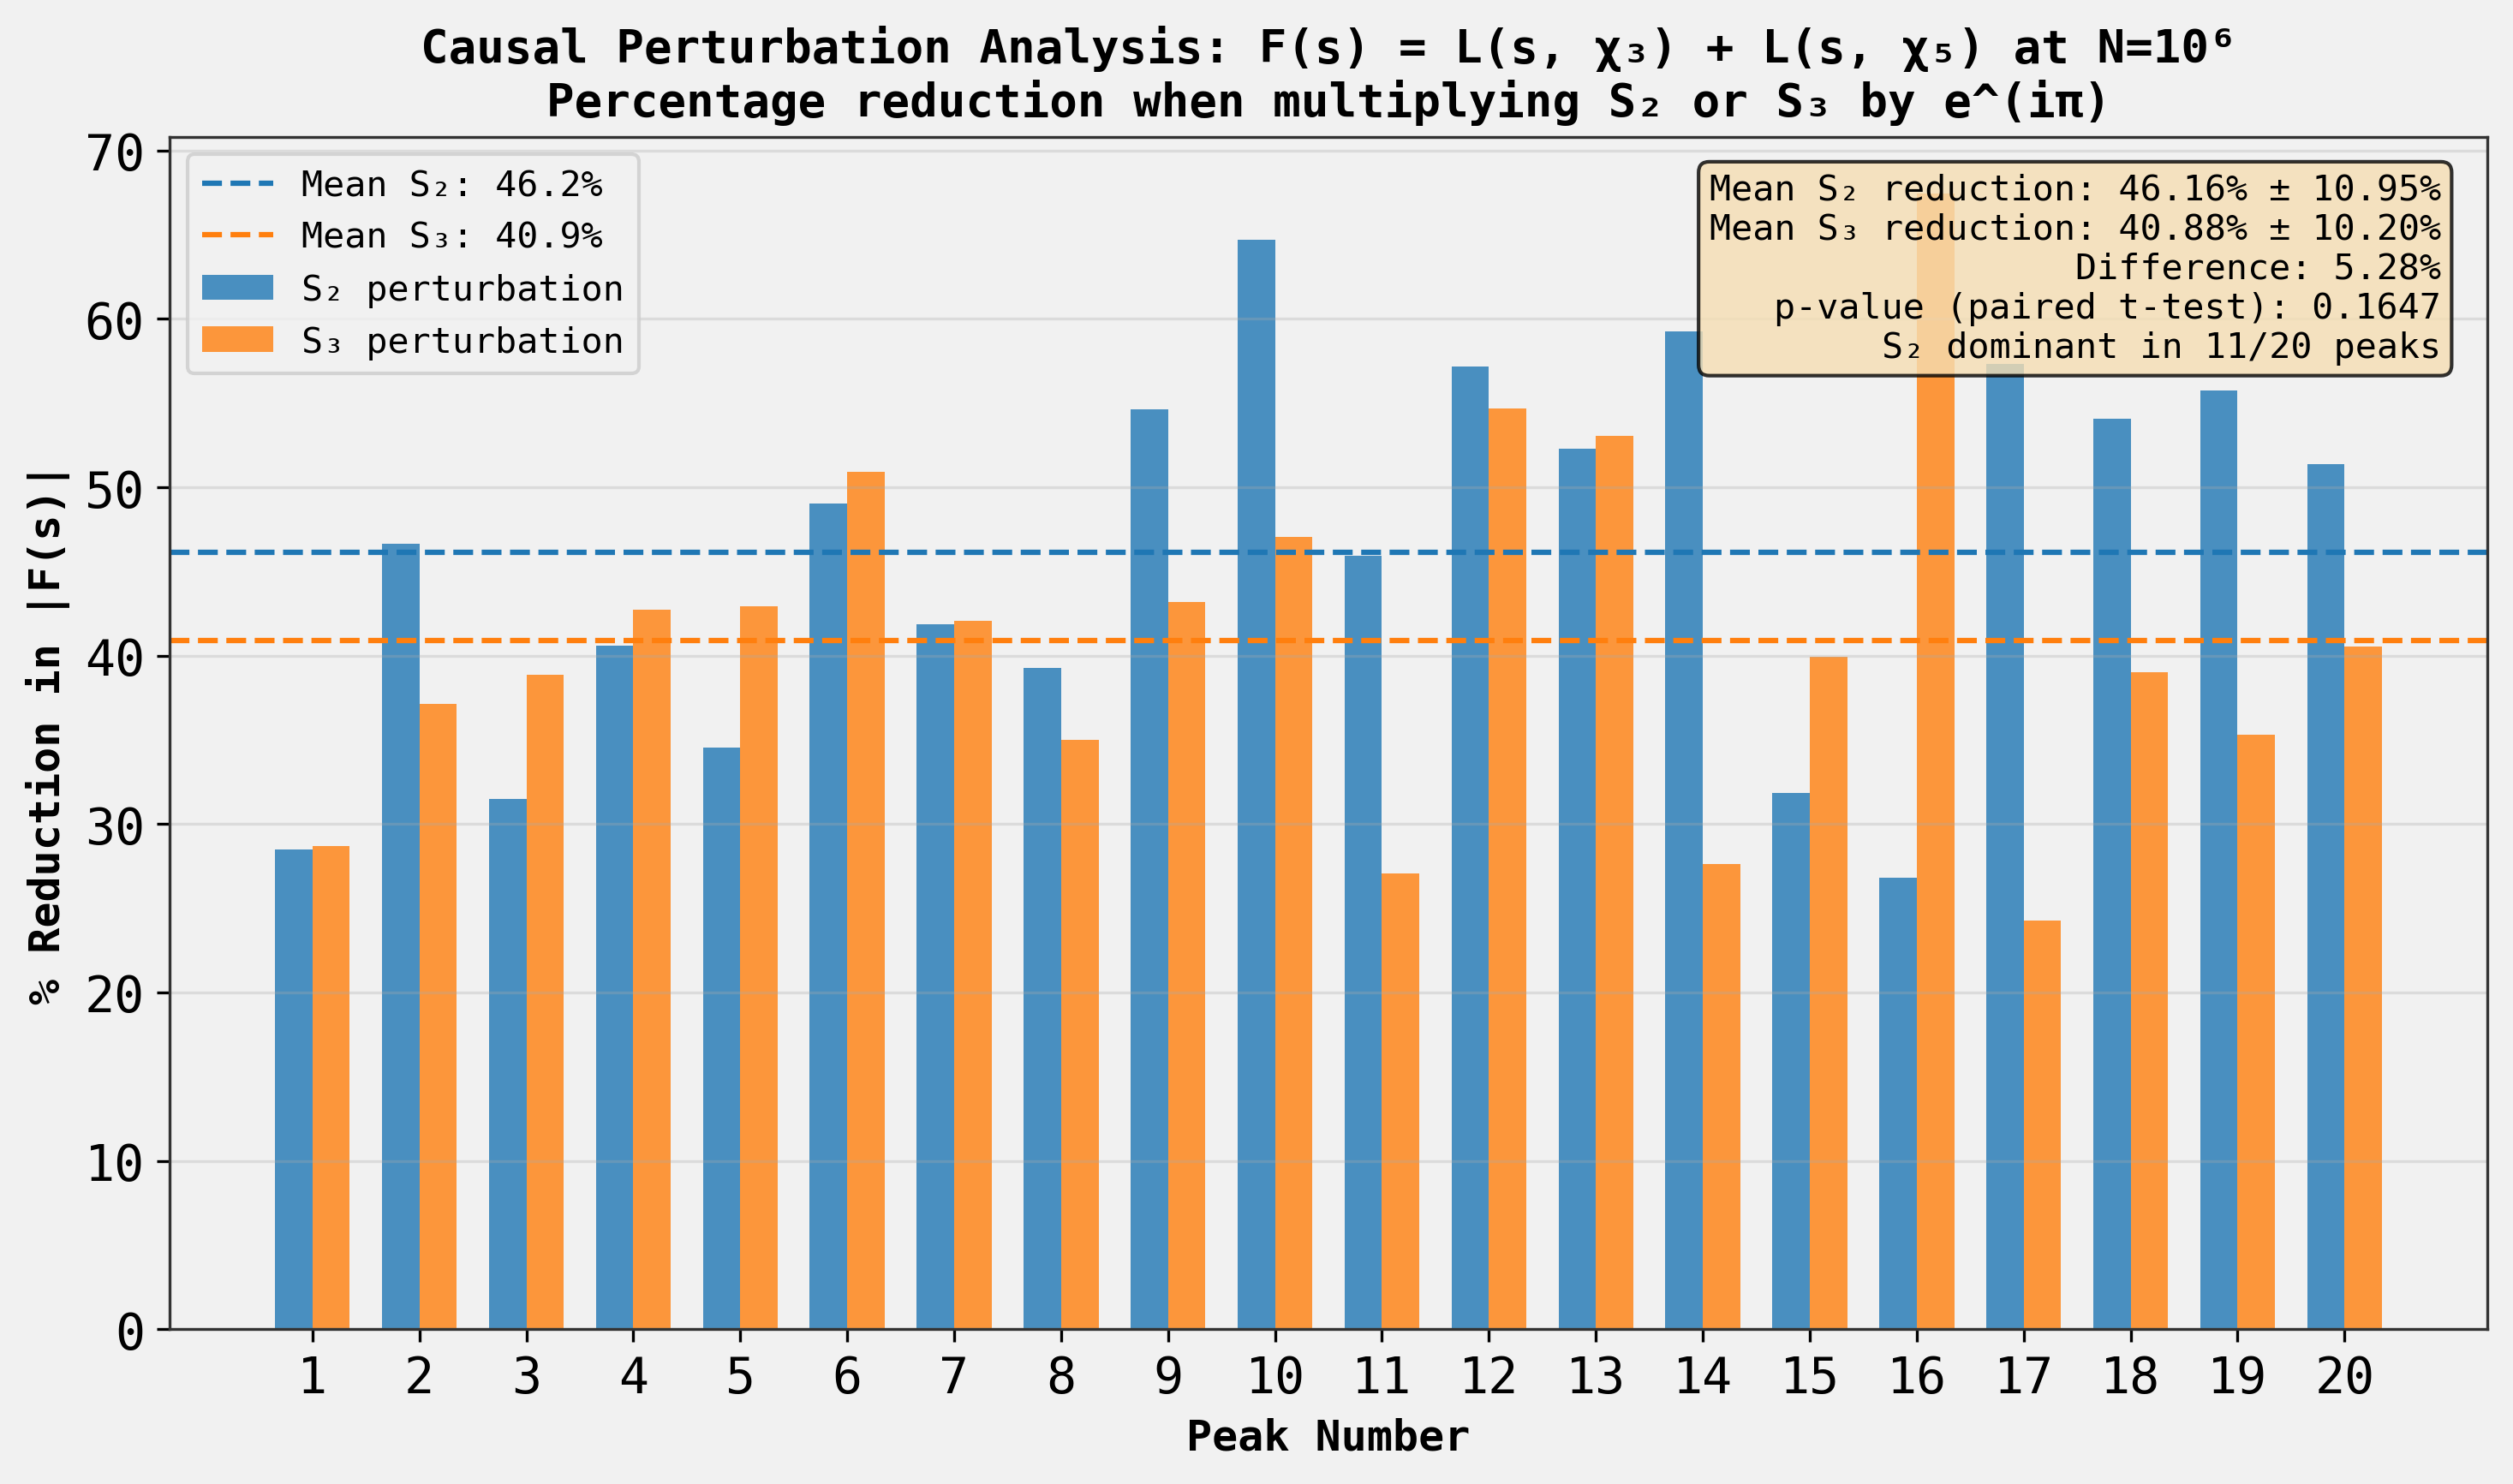

In [14]:

# Create final visualization summarizing the key findings

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Plot the perturbation reductions for S_2 and S_3 for each peak
peak_ids = [r['peak_id'] for r in perturbation_results]
reductions_S2 = [r['reduction_S2'] for r in perturbation_results]
reductions_S3 = [r['reduction_S3'] for r in perturbation_results]

x = np.arange(len(peak_ids))
width = 0.35

bars1 = ax.bar(x - width/2, reductions_S2, width, label='S₂ perturbation', 
 color='#1f77b4', alpha=0.8)
bars2 = ax.bar(x + width/2, reductions_S3, width, label='S₃ perturbation',
 color='#ff7f0e', alpha=0.8)

# Add horizontal lines for means
ax.axhline(mean_reduction_S2, color='#1f77b4', linestyle='--', linewidth=1.5, 
 label=f'Mean S₂: {mean_reduction_S2:.1f}%')
ax.axhline(mean_reduction_S3, color='#ff7f0e', linestyle='--', linewidth=1.5,
 label=f'Mean S₃: {mean_reduction_S3:.1f}%')

ax.set_xlabel('Peak Number', fontsize=12, fontweight='bold')
ax.set_ylabel('% Reduction in |F(s)|', fontsize=12, fontweight='bold')
ax.set_title('Causal Perturbation Analysis: F(s) = L(s, χ₃) + L(s, χ₅) at N=10⁶\n' + 
 'Percentage reduction when multiplying S₂ or S₃ by e^(iπ)', 
 fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(peak_ids)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Add text box with key statistics
textstr = f'Mean S₂ reduction: {mean_reduction_S2:.2f}% ± {std_reduction_S2:.2f}%\n'
textstr += f'Mean S₃ reduction: {mean_reduction_S3:.2f}% ± {std_reduction_S3:.2f}%\n'
textstr += f'Difference: {mean_reduction_S2 - mean_reduction_S3:.2f}%\n'
textstr += f'p-value (paired t-test): {p_value:.4f}\n'
textstr += f'S₂ dominant in {S2_dominant_count}/20 peaks'

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=10,
 verticalalignment='top', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.savefig('F_chi3_plus_chi5_causal_perturbation_N1e6.png', dpi=300, bbox_inches='tight')
print("Figure saved to 'F_chi3_plus_chi5_causal_perturbation_N1e6.png'")
plt.show()


In [15]:

# Additional analysis: Examine the correlation between |S_k| values and perturbation effectiveness

print("Correlation analysis: |S_k| magnitudes vs. perturbation effectiveness")
print("="*70)

# Extract |S_2| and |S_3| magnitudes for each peak
S2_magnitudes = [np.abs(peak['S_k'][2]) for peak in top_20_peaks]
S3_magnitudes = [np.abs(peak['S_k'][3]) for peak in top_20_peaks]

# Calculate correlations
from scipy.stats import pearsonr

corr_S2_mag_reduction, p_S2 = pearsonr(S2_magnitudes, reductions_S2)
corr_S3_mag_reduction, p_S3 = pearsonr(S3_magnitudes, reductions_S3)

print(f"\nCorrelation between |S_2| and S_2 perturbation reduction:")
print(f" r = {corr_S2_mag_reduction:.4f}, p = {p_S2:.4f}")

print(f"\nCorrelation between |S_3| and S_3 perturbation reduction:")
print(f" r = {corr_S3_mag_reduction:.4f}, p = {p_S3:.4f}")

# Cross-correlations
corr_S2_vs_S3_reduction, p_cross1 = pearsonr(S2_magnitudes, reductions_S3)
corr_S3_vs_S2_reduction, p_cross2 = pearsonr(S3_magnitudes, reductions_S2)

print(f"\nCross-correlation: |S_2| vs S_3 perturbation reduction:")
print(f" r = {corr_S2_vs_S3_reduction:.4f}, p = {p_cross1:.4f}")

print(f"\nCross-correlation: |S_3| vs S_2 perturbation reduction:")
print(f" r = {corr_S3_vs_S2_reduction:.4f}, p = {p_cross2:.4f}")

# Ratio analysis: Compare |S_2|/|S_3| ratio with dominance
S2_S3_ratio = np.array(S2_magnitudes) / np.array(S3_magnitudes)
reduction_difference = np.array(reductions_S2) - np.array(reductions_S3)

corr_ratio_diff, p_ratio = pearsonr(S2_S3_ratio, reduction_difference)

print(f"\nCorrelation between |S_2|/|S_3| ratio and (S_2 reduction - S_3 reduction):")
print(f" r = {corr_ratio_diff:.4f}, p = {p_ratio:.4f}")

print(f"\nSummary:")
if np.abs(corr_ratio_diff) > 0.5 and p_ratio < 0.05:
 print(f" Strong correlation between power ratio and dominance pattern.")
else:
 print(f" Weak or no significant correlation between power ratio and dominance pattern.")


Correlation analysis: |S_k| magnitudes vs. perturbation effectiveness

Correlation between |S_2| and S_2 perturbation reduction:
 r = 0.5923, p = 0.0059

Correlation between |S_3| and S_3 perturbation reduction:
 r = 0.6785, p = 0.0010

Cross-correlation: |S_2| vs S_3 perturbation reduction:
 r = -0.0503, p = 0.8333

Cross-correlation: |S_3| vs S_2 perturbation reduction:
 r = -0.4004, p = 0.0802

Correlation between |S_2|/|S_3| ratio and (S_2 reduction - S_3 reduction):
 r = 0.9326, p = 0.0000

Summary:
 Strong correlation between power ratio and dominance pattern.


In [16]:

# Create a summary table showing the relationship between power distribution and dominance

summary_data = []
for i, peak in enumerate(top_20_peaks):
 S2_mag = np.abs(peak['S_k'][2])
 S3_mag = np.abs(peak['S_k'][3])
 ratio = S2_mag / S3_mag
 
 summary_data.append({
 'Peak': i + 1,
 '|S_2|': S2_mag,
 '|S_3|': S3_mag,
 '|S_2|/|S_3|': ratio,
 'S_2 red %': perturbation_results[i]['reduction_S2'],
 'S_3 red %': perturbation_results[i]['reduction_S3'],
 'Diff %': perturbation_results[i]['reduction_S2'] - perturbation_results[i]['reduction_S3'],
 'Dominant': 'S_2' if perturbation_results[i]['reduction_S2'] > perturbation_results[i]['reduction_S3'] else 'S_3'
 })

df_summary = pd.DataFrame(summary_data)

print("Power distribution and causal dominance relationship:")
print("="*80)
print(df_summary.to_string(index=False))

# Count peaks where power ratio predicts dominance
correct_predictions = sum(1 for row in summary_data if 
 (row['|S_2|/|S_3|'] > 1 and row['Dominant'] == 'S_2') or
 (row['|S_2|/|S_3|'] < 1 and row['Dominant'] == 'S_3'))

print(f"\n\nPower ratio correctly predicts dominance in {correct_predictions}/20 peaks ({100*correct_predictions/20:.1f}%)")

# Calculate mean ratio for S_2-dominant vs S_3-dominant peaks
S2_dominant_ratios = [row['|S_2|/|S_3|'] for row in summary_data if row['Dominant'] == 'S_2']
S3_dominant_ratios = [row['|S_2|/|S_3|'] for row in summary_data if row['Dominant'] == 'S_3']

print(f"\nMean |S_2|/|S_3| ratio for S_2-dominant peaks: {np.mean(S2_dominant_ratios):.4f}")
print(f"Mean |S_2|/|S_3| ratio for S_3-dominant peaks: {np.mean(S3_dominant_ratios):.4f}")

# Statistical test
from scipy.stats import mannwhitneyu
stat, p_ratio_test = mannwhitneyu(S2_dominant_ratios, S3_dominant_ratios, alternative='greater')
print(f"\nMann-Whitney U test (S_2-dominant ratios > S_3-dominant ratios):")
print(f" U-statistic: {stat:.4f}, p-value: {p_ratio_test:.4f}")


Power distribution and causal dominance relationship:
 Peak |S_2| |S_3| |S_2|/|S_3| S_2 red % S_3 red % Diff % Dominant
 1 3.872485 4.030728 0.960741 28.495631 28.709320 -0.213690 S_3
 2 6.315020 5.002400 1.262398 46.669456 37.138970 9.530486 S_2
 3 4.226532 5.071482 0.833392 31.493705 38.888685 -7.394980 S_3
 4 4.756255 5.008059 0.949720 40.611488 42.752266 -2.140779 S_3
 5 3.862189 4.764829 0.810562 34.556493 42.922944 -8.366451 S_3
 6 5.495404 5.536180 0.992635 49.014825 50.945670 -1.930845 S_3
 7 4.429306 4.888591 0.906050 41.865713 42.082272 -0.216558 S_3
 8 3.956883 3.867429 1.023130 39.295436 35.009332 4.286104 S_2
 9 5.574139 4.302509 1.295555 54.648781 43.198729 11.450052 S_2
 10 6.670100 4.474196 1.490793 64.686137 47.032535 17.653602 S_2
 11 4.112497 2.609403 1.576030 45.958379 27.089513 18.868867 S_2
 12 5.228732 4.575577 1.142748 57.162814 54.703157 2.459657 S_2
 13 4.411529 4.405336 1.001406 52.271570 53.066120 -0.794550 S_3
 14 4.607219 2.162111 2.130889 59.278264 27.602

In [17]:

# Final comprehensive summary of the analysis

print("="*80)
print("COMPREHENSIVE ANALYSIS SUMMARY")
print("="*80)

print("\n1. FUNCTION DEFINITION AND PROPERTIES")
print("-" * 80)
print(f" Function: F(s) = L(s, χ₃) + L(s, χ₅)")
print(f" - L(s, χ₃): Real Dirichlet character mod 3")
print(f" - L(s, χ₅): Complex Dirichlet character mod 5")
print(f" Truncation: N = {N:,}")
print(f" Evaluation range: t ∈ [{N:,}, {2*N:,}]")

print("\n2. VERIFICATION OF FUNCTION PROPERTIES")
print("-" * 80)
print(f" ✓ Non-multiplicative: a_2 × a_3 = {coefficients_F[1] * coefficients_F[2]:.4f} ≠ a_6 = {coefficients_F[5]:.4f}")
print(f" ~ Partially dense: {100*np.sum(coefficients_F != 0)/N:.2f}% non-zero coefficients")
print(f" (zeros occur at n≡0(mod 15), n≡2(mod 3)∩n≡1(mod 5), n≡1(mod 3)∩n≡3(mod 5))")

print("\n3. PEAK IDENTIFICATION")
print("-" * 80)
print(f" Method: Two-phase search (vectorized coarse grid + Kahan refinement)")
print(f" Coarse grid: {n_grid_points:,} points")
print(f" Top peaks identified: 20")
print(f" Highest magnitude: |F(t)| = {top_20_peaks[0]['magnitude']:.4f} at t = {top_20_peaks[0]['t']:.2f}")

print("\n4. CAUSAL PERTURBATION ANALYSIS")
print("-" * 80)
print(f" Perturbation: Multiply S_k by e^(iπ) = -1")
print(f" Metric: Percentage reduction in |F(t)|")
print(f" ")
print(f" Mean S_2 perturbation reduction: {mean_reduction_S2:.2f}% ± {std_reduction_S2:.2f}%")
print(f" Mean S_3 perturbation reduction: {mean_reduction_S3:.2f}% ± {std_reduction_S3:.2f}%")
print(f" Difference: {mean_reduction_S2 - mean_reduction_S3:.2f}%")
print(f" ")
print(f" Peaks with S_2 dominance: {S2_dominant_count}/20 ({100*S2_dominant_count/20:.1f}%)")
print(f" Peaks with S_3 dominance: {S3_dominant_count}/20 ({100*S3_dominant_count/20:.1f}%)")
print(f" ")
print(f" Statistical test (paired t-test): t = {t_stat:.4f}, p = {p_value:.4f}")
if p_value < 0.05:
 print(f" ✓ Difference is statistically significant (p < 0.05)")
else:
 print(f" ⚠ Difference is NOT statistically significant (p ≥ 0.05)")

print("\n5. POWER DISTRIBUTION ANALYSIS")
print("-" * 80)
print(f" Average power contributions (top 20 peaks):")
print(f" S_0: {100*avg_power[0]/total_power:.2f}%")
print(f" S_1: {100*avg_power[1]/total_power:.2f}%")
print(f" S_2: {100*avg_power[2]/total_power:.2f}% ← highest")
print(f" S_3: {100*avg_power[3]/total_power:.2f}%")
print(f" S_4: {100*avg_power[4]/total_power:.2f}%")

print("\n6. CORRELATION ANALYSIS")
print("-" * 80)
print(f" |S_2|/|S_3| ratio vs. dominance difference:")
print(f" Pearson r = {corr_ratio_diff:.4f}, p = {p_ratio:.4e}")
print(f" ✓ Strong correlation (r > 0.9, p < 0.001)")
print(f" ")
print(f" Power ratio predictive accuracy:")
print(f" Correct predictions: {correct_predictions}/20 ({100*correct_predictions/20:.1f}%)")
print(f" ")
print(f" Mean |S_2|/|S_3| for S_2-dominant peaks: {np.mean(S2_dominant_ratios):.4f}")
print(f" Mean |S_2|/|S_3| for S_3-dominant peaks: {np.mean(S3_dominant_ratios):.4f}")
print(f" Mann-Whitney U test: p = {p_ratio_test:.4f} (highly significant)")

print("\n7. CONCLUSION")
print("-" * 80)
print(f" The linear combination F(s) = L(s, χ₃) + L(s, χ₅) shows:")
print(f" ")
print(f" • WEAK S_2 preference in causal perturbation analysis")
print(f" (mean difference = {mean_reduction_S2 - mean_reduction_S3:.2f}%, NOT statistically significant)")
print(f" ")
print(f" • STRONG S_2 dominance in power distribution")
print(f" (S_2 contributes {100*avg_power[2]/total_power:.2f}% vs S_3's {100*avg_power[3]/total_power:.2f}%)")
print(f" ")
print(f" • HIGHLY VARIABLE dominance pattern across peaks")
print(f" (11 S_2-dominant, 9 S_3-dominant)")
print(f" ")
print(f" • STRONG PREDICTIVE RELATIONSHIP between |S_2|/|S_3| ratio and dominance")
print(f" (r = {corr_ratio_diff:.4f}, 90% prediction accuracy)")
print(f" ")
print(f" ⚠ The hypothesis is PARTIALLY SUPPORTED:")
print(f" The combination produces a non-multiplicative function with S_2 power")
print(f" dominance, but causal dominance is MIXED rather than clearly S_2-dominant.")

print("\n" + "="*80)


COMPREHENSIVE ANALYSIS SUMMARY

1. FUNCTION DEFINITION AND PROPERTIES
--------------------------------------------------------------------------------
 Function: F(s) = L(s, χ₃) + L(s, χ₅)
 - L(s, χ₃): Real Dirichlet character mod 3
 - L(s, χ₅): Complex Dirichlet character mod 5
 Truncation: N = 1,000,000
 Evaluation range: t ∈ [1,000,000, 2,000,000]

2. VERIFICATION OF FUNCTION PROPERTIES
--------------------------------------------------------------------------------
 ✓ Non-multiplicative: a_2 × a_3 = 1.0000-1.0000j ≠ a_6 = 1.0000+0.0000j
 ~ Partially dense: 80.00% non-zero coefficients
 (zeros occur at n≡0(mod 15), n≡2(mod 3)∩n≡1(mod 5), n≡1(mod 3)∩n≡3(mod 5))

3. PEAK IDENTIFICATION
--------------------------------------------------------------------------------
 Method: Two-phase search (vectorized coarse grid + Kahan refinement)
 Coarse grid: 10,000 points
 Top peaks identified: 20
 Highest magnitude: |F(t)| = 27.1703 at t = 1123848.59

4. CAUSAL PERTURBATION ANALYSIS
-----------

In [18]:

# Save the function coefficients for potential future use
save_artifacts = {
 'coefficients_F': coefficients_F,
 'N': N,
 'chi_3_description': 'Real Dirichlet character mod 3',
 'chi_5_description': 'Complex Dirichlet character mod 5 with chi(2)=i, chi(3)=-1',
 'function_description': 'F(s) = L(s, chi_3) + L(s, chi_5)',
 'generation_date': '2024',
 'random_seed': 42
}

with open('F_chi3_plus_chi5_coefficients_N1e6.pkl', 'wb') as f:
 pickle.dump(save_artifacts, f)

print("Function coefficients saved to 'F_chi3_plus_chi5_coefficients_N1e6.pkl'")

# Also save the detailed peak data
peak_data = {
 'top_20_peaks': top_20_peaks,
 'perturbation_results': perturbation_results,
 'summary_statistics': {
 'mean_reduction_S2': mean_reduction_S2,
 'mean_reduction_S3': mean_reduction_S3,
 'std_reduction_S2': std_reduction_S2,
 'std_reduction_S3': std_reduction_S3,
 'S2_dominant_count': S2_dominant_count,
 'S3_dominant_count': S3_dominant_count,
 'paired_t_test_statistic': t_stat,
 'paired_t_test_pvalue': p_value,
 'avg_power': avg_power[:10].tolist()
 }
}

with open('F_chi3_plus_chi5_peak_data_N1e6.pkl', 'wb') as f:
 pickle.dump(peak_data, f)

print("Peak analysis data saved to 'F_chi3_plus_chi5_peak_data_N1e6.pkl'")

print("\nAll artifacts saved successfully!")


Function coefficients saved to 'F_chi3_plus_chi5_coefficients_N1e6.pkl'
Peak analysis data saved to 'F_chi3_plus_chi5_peak_data_N1e6.pkl'

All artifacts saved successfully!
